# Fine-Tuning SRCNN on Gameplay Dataset

## Objective

Fine-tune the pre-trained SRCNN model using a gameplay image dataset in order to adapt the network to the videogame domain before testing it on retro games.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from src.models.srcnn import SRCNN
from src.checkpoint import load_model, save_model

from src.gameplay_dataset import GameplayDataset

from src.train import train_one_epoch
from src.evaluate import evaluate

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
dataset = GameplayDataset(
    "../data/gameplay_dataset"
)

print(len(dataset))

10000


In [5]:
train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [6]:
model = SRCNN().to(device)

model = load_model(
    model,
    "../results/checkpoints/srcnn_best.pth",
    device
)

print(model)

SRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): ReLU(inplace=True)
  )
  (mapping): Sequential(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (reconstruction): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)


In [7]:
criterion = nn.L1Loss()

optimizer = Adam(
    model.parameters(),
    lr=5e-5
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [8]:
TRAIN_EPOCHS = 30
best_loss = float("inf")

train_loss_history = []
train_psnr_history = []

print("Fine-tuning started...")

Fine-tuning started...


In [9]:
for epoch in range(TRAIN_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    train_loss_history.append(train_loss)

    scheduler.step(train_loss)

    print(
        f"Epoch {epoch+1}/{TRAIN_EPOCHS} | "
        f"Loss: {train_loss:.6f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.8f}"
    )

    if train_loss < best_loss:

        best_loss = train_loss

        save_model(
            model,
            "../results/checkpoints/srcnn_retro_l1_best.pth"
        )

        print("Best model saved!")

Epoch 1/30 | Loss: 0.019553 | LR: 0.00005000
Best model saved!
Epoch 2/30 | Loss: 0.018744 | LR: 0.00005000
Best model saved!
Epoch 3/30 | Loss: 0.018303 | LR: 0.00005000
Best model saved!
Epoch 4/30 | Loss: 0.018311 | LR: 0.00005000
Epoch 5/30 | Loss: 0.017890 | LR: 0.00005000
Best model saved!
Epoch 6/30 | Loss: 0.017518 | LR: 0.00005000
Best model saved!
Epoch 7/30 | Loss: 0.017466 | LR: 0.00005000
Best model saved!
Epoch 8/30 | Loss: 0.017628 | LR: 0.00005000
Epoch 9/30 | Loss: 0.017003 | LR: 0.00005000
Best model saved!
Epoch 10/30 | Loss: 0.016862 | LR: 0.00005000
Best model saved!
Epoch 11/30 | Loss: 0.016966 | LR: 0.00005000
Epoch 12/30 | Loss: 0.016717 | LR: 0.00005000
Best model saved!
Epoch 13/30 | Loss: 0.016707 | LR: 0.00005000
Best model saved!
Epoch 14/30 | Loss: 0.016545 | LR: 0.00005000
Best model saved!
Epoch 15/30 | Loss: 0.016529 | LR: 0.00005000
Best model saved!
Epoch 16/30 | Loss: 0.016456 | LR: 0.00005000
Best model saved!
Epoch 17/30 | Loss: 0.016127 | LR: 0.00

In [10]:
import json

history = {
    "train_loss": train_loss_history
}

with open(
    "../results/metrics/srcnn_retro_training_history.json",
    "w"
) as f:

    json.dump(history, f, indent=4)

print("History saved!")

History saved!


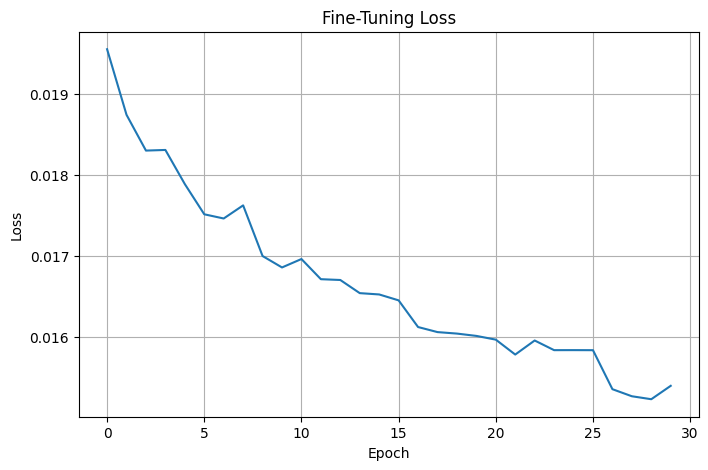

In [11]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_history)

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()